In [4]:
import os

paths = [
    '/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset',
    '/kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd'
]

for dataset_path in paths:
    print(f"\n=== {dataset_path} ===")
    for root, dirs, files in os.walk(dataset_path):
        level = root.replace(dataset_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 3:
            subindent = ' ' * 2 * (level + 1)
            for file in files[:3]:
                print(f'{subindent}{file}')


=== /kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset ===
real-life-violence-situations-dataset/
  real life violence situations/
    Real Life Violence Dataset/
      NonViolence/
      Violence/
  Real Life Violence Dataset/
    NonViolence/
      NV_759.mp4
      NV_564.mp4
      NV_126.mp4
    Violence/
      V_465.mp4
      V_313.mp4
      V_753.mp4

=== /kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd ===
smartcity-cctv-violence-detection-dataset-scvd/
  SCVD/
    SCVD_converted_sec_split/
      Test/
        Weaponized/
        Normal/
        Violence/
      Train/
        Weaponized/
        Normal/
        Violence/
    SCVD_converted/
      Test/
        Weaponized/
        Normal/
        Violence/
      Train/
        Weaponized/
        Normal/
        Violence/


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [11]:
def count_videos(dataset_path, ext='.avi'):
    counts = {}
    for split in os.listdir(dataset_path):
        split_path = os.path.join(dataset_path, split)
        if os.path.isdir(split_path):
            for cls in os.listdir(split_path):
                cls_path = os.path.join(split_path, cls)
                if os.path.isdir(cls_path):
                    key = f"{split}/{cls}"
                    counts[key] = len([f for f in os.listdir(cls_path) if f.endswith(ext)])
    return counts

scvd_counts = count_videos(SCVD_PATH, ext='.avi')

print("=== SCVD Dataset ===")
for k, v in scvd_counts.items():
    print(f"  {k}: {v} videos")

=== SCVD Dataset ===
  Test/Weaponized: 24 videos
  Test/Normal: 46 videos
  Test/Violence: 12 videos
  Train/Weaponized: 100 videos
  Train/Normal: 200 videos
  Train/Violence: 99 videos


In [16]:
# Cell 3 
rlvd_sample = os.path.join(RLVD_PATH, 'Violence', 'V_465.mp4')
scvd_sample_file = os.path.join(SCVD_PATH, 'Train', 'Violence', 'v070_converted.avi')

print("RLVD sample:", inspect_video(rlvd_sample))
print("SCVD sample:", inspect_video(scvd_sample_file))

RLVD sample: {'fps': 29.97, 'frames': 141, 'width': 1280, 'height': 720, 'duration_sec': 4.7}
SCVD sample: {'fps': 30.0, 'frames': 218, 'width': 1280, 'height': 720, 'duration_sec': 7.27}


In [17]:
def preprocess_video(video_path, output_size=(224, 224), num_frames=16):
    """
    Extract num_frames evenly spaced frames from a video.
    Resize to output_size and normalize to [0, 1].
    Returns numpy array of shape (num_frames, H, W, 3)
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        cap.release()
        return None
    
    # Pick evenly spaced frame indices
    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []
    
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)   # BGR → RGB
        frame = cv2.resize(frame, output_size)            # Resize to 224x224
        frame = frame / 255.0                             # Normalize to [0,1]
        frames.append(frame)
    
    cap.release()
    
    if len(frames) < num_frames:
        return None
        
    return np.array(frames)  # shape: (16, 224, 224, 3)

# Test on one video
sample_frames = preprocess_video(rlvd_sample)
print("Output shape:", sample_frames.shape)
print("Min value:", sample_frames.min(), "| Max value:", sample_frames.max())

Output shape: (16, 224, 224, 3)
Min value: 0.0 | Max value: 1.0


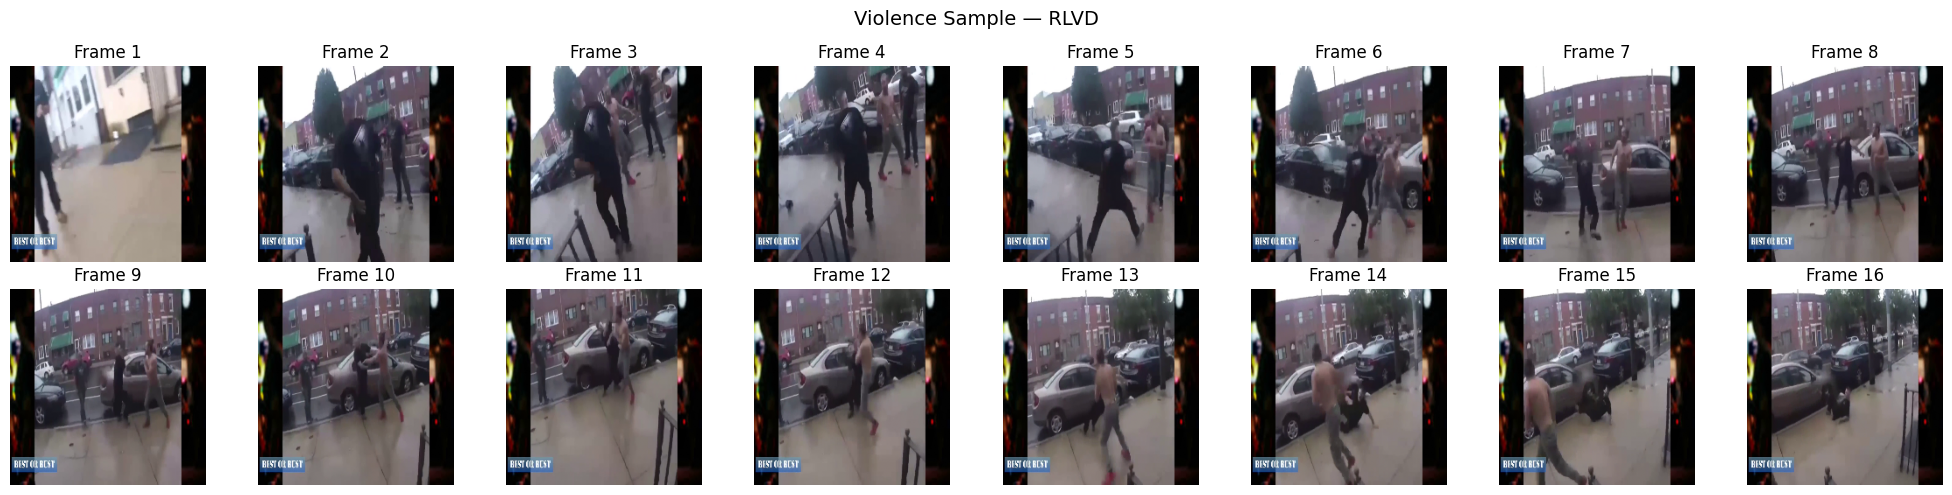

In [18]:
def visualize_frames(frames, title="Extracted Frames"):
    fig, axes = plt.subplots(2, 8, figsize=(20, 5))
    fig.suptitle(title, fontsize=14)
    for i, ax in enumerate(axes.flat):
        ax.imshow(frames[i])
        ax.axis('off')
        ax.set_title(f"Frame {i+1}")
    plt.tight_layout()
    plt.show()

visualize_frames(sample_frames, title="Violence Sample — RLVD")

In [19]:
# Cell 6 — Full Pipeline Verification + Metadata CSV

VIDEO_EXTENSIONS = {'.mp4', '.avi'}

def build_metadata(dataset_name, base_path, structure='flat'):
    """
    structure='flat'  → base_path/ClassName/video.mp4  (RLVD)
    structure='split' → base_path/Split/ClassName/video.avi (SCVD)
    """
    records = []
    
    if structure == 'flat':
        for cls in os.listdir(base_path):
            cls_path = os.path.join(base_path, cls)
            if not os.path.isdir(cls_path):
                continue
            for f in os.listdir(cls_path):
                if os.path.splitext(f)[1].lower() in VIDEO_EXTENSIONS:
                    records.append({
                        'dataset': dataset_name,
                        'split': 'train',  # RLVD has no predefined split
                        'class': cls,
                        'filepath': os.path.join(cls_path, f)
                    })
    
    elif structure == 'split':
        for split in os.listdir(base_path):
            split_path = os.path.join(base_path, split)
            if not os.path.isdir(split_path):
                continue
            for cls in os.listdir(split_path):
                cls_path = os.path.join(split_path, cls)
                if not os.path.isdir(cls_path):
                    continue
                for f in os.listdir(cls_path):
                    if os.path.splitext(f)[1].lower() in VIDEO_EXTENSIONS:
                        records.append({
                            'dataset': dataset_name,
                            'split': split.lower(),
                            'class': cls,
                            'filepath': os.path.join(cls_path, f)
                        })
    
    return records

# Build metadata for both
rlvd_records = build_metadata('RLVD', RLVD_PATH, structure='flat')
scvd_records  = build_metadata('SCVD', SCVD_PATH, structure='split')

all_records = rlvd_records + scvd_records
df = pd.DataFrame(all_records)

print("Total videos indexed:", len(df))
print("\nBreakdown:")
print(df.groupby(['dataset', 'split', 'class']).size().to_string())

# Save metadata CSV
df.to_csv('dataset_metadata.csv', index=False)
print("\nMetadata saved to dataset_metadata.csv ✅")

Total videos indexed: 2481

Breakdown:
dataset  split  class      
RLVD     train  NonViolence    1000
                Violence       1000
SCVD     test   Normal           46
                Violence         12
                Weaponized       24
         train  Normal          200
                Violence         99
                Weaponized      100

Metadata saved to dataset_metadata.csv ✅


In [20]:
# Cell 7 — Pipeline Validation (test preprocessing on sample from each class)

results = []

for (dataset, split, cls), group in df.groupby(['dataset', 'split', 'class']):
    sample_path = group['filepath'].iloc[0]  # take first video of each group
    frames = preprocess_video(sample_path)
    status = '✅ OK' if frames is not None else '❌ FAILED'
    results.append({
        'dataset': dataset,
        'split': split,
        'class': cls,
        'sample_file': os.path.basename(sample_path),
        'status': status
    })
    print(f"{dataset} | {split} | {cls} → {status}")

print("\nAll checks done.")

RLVD | train | NonViolence → ✅ OK
RLVD | train | Violence → ✅ OK
SCVD | test | Normal → ✅ OK
SCVD | test | Violence → ✅ OK
SCVD | test | Weaponized → ✅ OK
SCVD | train | Normal → ✅ OK
SCVD | train | Violence → ✅ OK
SCVD | train | Weaponized → ✅ OK

All checks done.
